In [1]:
import os
# os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

import sys

sys.path.insert(0, "../..")

In [2]:
import chex
import jax
import jax.numpy as jnp
import jax.random as jrandom
import math
import matplotlib.pyplot as plt
import numpy as np
import optax

from flax import nnx
from functools import partial
from jax_tqdm import loop_tqdm
from tqdm.notebook import tqdm
from typing import Any, NamedTuple

from src.decoding import make_autoregressive
from src.models.attention import quiet_dot_product_attention
from src.models.gpt import InContextGPTWithThoughts
from src.models.rnn import InContextGRUWithThoughts
from src.models.next_token import TokenEmbedders
from src.models.nope import NoPE
from src.models import TrainState

## Hyperparameters

In [3]:
num_blocks = 2
num_heads = 2
embed_dim = 16
widening_factor = 4
dtype = jnp.float32

num_input_tokens = 5 # 0, 1, latent start, latent end, EOS
num_output_tokens = 2
start_thinking_token = 2
end_thinking_token = 3
eos_token = 4

train_type = "ntp" # ["ntp", "rl"]
task = "decision" # ["decision", "generation"]
complexity = "linear" # ["constant", "linear", "quadratic"]
# attention_fn = quiet_dot_product_attention
attention_fn = nnx.dot_product_attention
use_skip_connection = True
model_type = "gpt" # ["rnn", "gpt"]

read_budget = 5
thought_budget = 1

lr = 3e-4
# max_grad_norm = 1.0
max_grad_norm = False
max_iter = 100000
max_eval_iter = 50000
log_interval = 1000
print_rate = 1000

max_input_len = 5 + 1 # Includes start thinking token
max_read_len = max_input_len * 2 - 1
max_thought_len = max_input_len
max_output_len = 1 if "decision" else max_input_len - 1
num_questions = 64
rollout_samples = 1

think_phase_len = max_thought_len + max_input_len
output_phase_len = max_thought_len + max_input_len + max_output_len
batch_size = int(rollout_samples * num_questions)

seed = 42
rngs = nnx.Rngs(seed)
sample_rng = jrandom.PRNGKey(seed)
rollout_rng = jrandom.split(sample_rng, batch_size)

In [4]:
if complexity == "constant":
    def complexity_fn(input_len):
        return jnp.ones_like(input_len) * thought_budget
elif complexity == "linear":
    def complexity_fn(input_len):
        return input_len * thought_budget
elif complexity == "quadratic":
    def complexity_fn(input_len):
        return (input_len ** 2) * thought_budget
else:
    raise NotImplementedError

if complexity != "constant":
    read_budget = max_input_len

In [5]:
if model_type == "gpt":
    model = InContextGPTWithThoughts(
        num_blocks,
        num_heads,
        embed_dim,
        widening_factor,
        partial(
            TokenEmbedders,
            num_input_tokens=num_input_tokens,
            num_output_tokens=num_output_tokens,
            embed_dim=embed_dim,
            rngs=rngs,
            shared_decoding=True,
            decode=False,
            dtype=dtype,
        ),
        partial(NoPE),
        rngs,
        attention_fn=attention_fn,
    )
elif model_type == "rnn":
    model = InContextGRUWithThoughts(
        embed_dim,
        partial(
            TokenEmbedders,
            num_input_tokens=num_input_tokens,
            num_output_tokens=num_output_tokens,
            embed_dim=embed_dim,
            rngs=rngs,
            shared_decoding=True,
            decode=False,
            dtype=dtype,
        ),
        rngs,
    )
else:
    raise NotImplementedError

graphdef, params, rest = nnx.split(model, nnx.Param, ...)

opt_transforms = []
if max_grad_norm:
    opt_transforms.append(
        optax.clip_by_global_norm(max_grad_norm)
    )
opt_transforms.append(optax.adam(lr))
opt = optax.chain(*opt_transforms)

train_state = TrainState.create(
    apply_fn=graphdef.apply,
    params=params,
    tx=opt,
    graphdef=graphdef,
    rest=rest,
)

TODO:
- The latent thought can be done without parallelizing first---parallelization at output phase
- Right now this is trained end-to-end, perhaps we can do an alternate training for RL setting
- Want constant compute so the model can't read more than certain amounts [x]
- Fix RNN to have cache
- Add logging to keep track of input length over training [x]

## Rollout and utils helpers

In [6]:
class ReadStepState(NamedTuple):
    graphdef: Any
    rest: Any
    cache: Any
    last_prompt_idx: int
    question_embedding: chex.Array
    last_output: chex.Array

class ThinkStepState(NamedTuple):
    graphdef: Any
    rest: Any
    cache: Any
    thought_length: int
    thought: chex.Array

class ActStepState(NamedTuple):
    graphdef: Any
    rest: Any
    cache: Any
    eos_token: int
    rng: jrandom.PRNGKey
    act_embeds: chex.Array
    logits: chex.Array
    actions: chex.Array
    eos: chex.Array
    last_read_output: chex.Array
    deterministic: int = 0

class TeacherForcingStepState(NamedTuple):
    graphdef: Any
    rest: Any
    cache: Any
    rng: jrandom.PRNGKey
    act_embeds: chex.Array
    logits: chex.Array
    actions: chex.Array
    last_read_output: chex.Array


def get_default(embed_seq):
    return jnp.zeros_like(embed_seq)

def select_new_cache(new_cache, cache):
    return new_cache

def select_old_cache(new_cache, cache):
    return cache

def _read_token(
    step_i,
    graphdef,
    cache,
    rest,
    last_prompt_idx,
    question_embedding,
    last_output,
):
    module = nnx.merge(graphdef, cache, rest)
    module.eval()
    module.set_attributes(deterministic=True, decode=True)

    is_prompt = step_i <= last_prompt_idx # The start think token is read at last_prompt_idx
    next_output = module.get_next_embedding_prediction(
        question_embedding[:, [step_i]],
    )[:, 0]
    new_cache = nnx.state(module, nnx.Cache)

    last_output = jax.lax.select(
        is_prompt,
        next_output,
        last_output,
    )

    cache = nnx.cond(
        is_prompt,
        select_new_cache,
        select_old_cache,
        new_cache,
        cache,
    )

    return cache, last_output

def _think_token(
    step_i,
    graphdef,
    cache,
    rest,
    thought_length,
    thought,
):
    module = nnx.merge(graphdef, cache, rest)
    module.eval()
    module.set_attributes(deterministic=True, decode=True)

    is_thought = step_i < thought_length - 1 # The start think is the last read token
    next_output = module.get_next_embedding_prediction(
        thought[:, [step_i]],
    )[:, 0]
    new_cache = nnx.state(module, nnx.Cache)

    last_output = jax.lax.select(
        is_thought,
        next_output,
        thought[:, step_i + 1],
    )

    cache = nnx.cond(
        is_thought,
        select_new_cache,
        select_old_cache,
        new_cache,
        cache,
    )

    return cache, last_output

def _act_token(
    step_i,
    graphdef,
    cache,
    rest,
    eos_token,
    rng,
    actions,
    eos,
    deterministic,
    last_read_output,
):
    rng, rng_step = jrandom.split(rng)
    module = nnx.merge(graphdef, cache, rest)
    module.eval()
    module.set_attributes(deterministic=True, decode=True)

    action_embedding = module.get_embedding(actions[:, [step_i]])
    act_embed = module.get_next_embedding_prediction(
        action_embedding
    )[:, 0]
    act_embed = act_embed + jax.lax.select(
        step_i == 0,
        last_read_output,
        jnp.zeros_like(last_read_output),
    ) # Establish a skip connection
    cache = nnx.state(module, nnx.Cache)
    
    logit = module.get_unembedding(act_embed)
    
    action = jax.lax.cond(
        deterministic,
        lambda rng_step, logit: jnp.argmax(logit, axis=-1),
        jrandom.categorical,
        rng_step,
        logit,
    )

    is_eos = jnp.logical_or(
        action == eos_token,
        eos[:, step_i],
    )

    return cache, act_embed, logit, action, is_eos, rng

def _teacher_forcing_token(
    step_i,
    graphdef,
    cache,
    rest,
    rng,
    actions,
    last_read_output,
):
    rng, _ = jrandom.split(rng)
    module = nnx.merge(graphdef, cache, rest)
    module.eval()
    module.set_attributes(deterministic=True, decode=True)

    action_embedding = module.get_embedding(actions[:, [step_i]])
    act_embed = module.get_next_embedding_prediction(
        action_embedding
    )[:, 0]
    act_embed = act_embed + jax.lax.select(
        step_i == 0,
        last_read_output,
        jnp.zeros_like(last_read_output),
    ) # Establish a skip connection
    cache = nnx.state(module, nnx.Cache)
    
    logit = module.get_unembedding(act_embed)

    return cache, act_embed, logit, rng

read_token = jax.vmap(_read_token, in_axes=[None, None, 0, 0, 0, 0, 0])
think_token = jax.vmap(_think_token, in_axes=[None, None, 0, 0, 0, 0])
act_token = jax.vmap(_act_token, in_axes=[None, None, 0, 0, 0, 0, 0, 0, 0, 0])
teacher_forcing_token = jax.vmap(_teacher_forcing_token, in_axes=[None, None, 0, 0, 0, 0, 0])


def read_step(
    step_i: int,
    step_state: ReadStepState,
):
    cache, last_output = read_token(
        step_i,
        step_state.graphdef,
        step_state.cache,
        step_state.rest,
        step_state.last_prompt_idx,
        step_state.question_embedding,
        step_state.last_output,
    )
    
    return ReadStepState(
        graphdef=step_state.graphdef,
        rest=step_state.rest,
        cache=cache,
        question_embedding=step_state.question_embedding,
        last_prompt_idx=step_state.last_prompt_idx,
        last_output=last_output,
    )

def think_step(
    step_i: int,
    step_state: ThinkStepState,
):
    cache, last_output = think_token(
        step_i,
        step_state.graphdef,
        step_state.cache,
        step_state.rest,
        step_state.thought_length,
        step_state.thought,
    )
    
    return ThinkStepState(
        graphdef=step_state.graphdef,
        rest=step_state.rest,
        cache=cache,
        thought_length=step_state.thought_length,
        thought=step_state.thought.at[:, :, step_i + 1].set(last_output),
    )

def act_step(
    step_i: int,
    step_state: ActStepState,
):
    cache, act_embed, logit, action, is_eos, rng = act_token(
        step_i,
        step_state.graphdef,
        step_state.cache,
        step_state.rest,
        step_state.eos_token,
        step_state.rng,
        step_state.actions,
        step_state.eos,
        step_state.deterministic,
        step_state.last_read_output,
    )
    
    return ActStepState(
        graphdef=step_state.graphdef,
        rest=step_state.rest,
        cache=cache,
        eos_token=step_state.eos_token,
        rng=rng,
        act_embeds=step_state.act_embeds.at[:, :, step_i + 1].set(act_embed),
        logits=step_state.logits.at[:, :, step_i + 1].set(logit),
        actions=step_state.actions.at[:, :, step_i + 1].set(action),
        eos=step_state.eos.at[:, :, step_i + 1].set(is_eos),
        deterministic=step_state.deterministic,
        last_read_output=step_state.last_read_output,
    )

def teacher_forcing_step(
    step_i: int,
    step_state: TeacherForcingStepState,
):
    cache, act_embed, logit, rng = teacher_forcing_token(
        step_i,
        step_state.graphdef,
        step_state.cache,
        step_state.rest,
        step_state.rng,
        step_state.actions,
        step_state.last_read_output,
    )
    
    return TeacherForcingStepState(
        graphdef=step_state.graphdef,
        rest=step_state.rest,
        cache=cache,
        rng=rng,
        act_embeds=step_state.act_embeds.at[:, :, step_i + 1].set(act_embed),
        logits=step_state.logits.at[:, :, step_i + 1].set(logit),
        actions=step_state.actions,
        last_read_output=step_state.last_read_output,
    )

### Utils

In [7]:
def match_action(action, answer, answer_len):
    match_mask = jnp.zeros(len(action))
    match_mask = match_mask.at[answer_len].set(1)
    match_mask = jnp.cumsum(match_mask)
    return {
        "success": jnp.all((action == answer) * (1 - match_mask) + match_mask).astype(int),
        "mask": 1 - match_mask,
    }


In [8]:
def l2_norm(params):
    return sum(jnp.sum(p**2) for p in jax.tree_util.tree_leaves(params))

In [9]:
def process_batch(
    question,
    answer,
    last_prompt_idx,
    thought_length,
    answer_length,
):
    question = jnp.repeat(
        question,
        rollout_samples,
        axis=0,
    )
    answer = jnp.repeat(
        answer,
        rollout_samples,
        axis=0,
    )
    last_prompt_idx = jnp.repeat(
        last_prompt_idx,
        rollout_samples,
        axis=0,
    )
    thought_length = jnp.repeat(
        thought_length,
        rollout_samples,
        axis=0,
    )
    answer_length = jnp.repeat(
        answer_length,
        rollout_samples,
        axis=0,
    )

    question = jax.device_put(question)
    answer = jax.device_put(answer)
    last_prompt_idx = jax.device_put(last_prompt_idx)
    thought_length = jax.device_put(thought_length)
    answer_length = jax.device_put(answer_length)

    return (
        question,
        answer,
        last_prompt_idx,
        thought_length,
        answer_length,
    )

## E2E-NTP

In [35]:
def make_ntp_loss(read_budget):
    def compute_ntp_loss(params, batch, rollout_rng):
        question = batch["question"]
        answer = batch["answer"]
        last_prompt_idx = batch["last_prompt_idx"]
        thought_length = batch["thought_length"]
        answer_length = batch["answer_length"]

        thought_length = jax.lax.select(
            read_budget - 1 < last_prompt_idx,
            jnp.ones_like(thought_length),
            thought_length - (last_prompt_idx - read_budget + 1),
        )
        last_prompt_idx = jax.lax.select(
            read_budget - 1 < last_prompt_idx,
            jnp.full_like(
                last_prompt_idx,
                fill_value=read_budget - 1,
            ),
            last_prompt_idx,
        )

        # total_len = last_prompt_idx + thought_length + answer_length
        module = nnx.merge(train_state.graphdef, params, train_state.rest)
        _, init_cache = make_autoregressive(
            module,
            max_decode_len=output_phase_len,
            batch_size=1,
            embed_dim=embed_dim,
            dtype=dtype,
            eval_mode=True,
        )
        cache = init_cache()
        graphdef, _, rest = nnx.split(module, nnx.Cache, ...)

        question_embedding = module.get_embedding(question)

        def initialize_read_step_state(question_embedding, last_prompt_idx):
            return ReadStepState(
                graphdef=graphdef,
                rest=rest,
                cache=cache,
                question_embedding=question_embedding,
                last_prompt_idx=last_prompt_idx,
                last_output=jnp.zeros((1, embed_dim)),
            )

        def initialize_think_step_state(thought_length, last_read_output, read_cache):
            thought = jnp.zeros((1, max_thought_len, embed_dim))
            thought = thought.at[:, 0].set(last_read_output)
            return ThinkStepState(
                graphdef=graphdef,
                rest=rest,
                cache=read_cache,
                thought_length=thought_length,
                thought=thought,
            )

        def initialize_teacher_forcing_step_state(think_cache, last_read_output, rng):
            actions = jnp.zeros((1, max_output_len + 1), dtype=int)
            actions = actions.at[:, 0].set(end_thinking_token)
            return TeacherForcingStepState(
                graphdef=graphdef,
                rest=rest,
                cache=think_cache,
                rng=rng,
                act_embeds=jnp.zeros((1, max_output_len + 1, embed_dim)),
                logits=jnp.zeros((1, max_output_len + 1, num_output_tokens)),
                actions=actions,
                last_read_output=last_read_output,
            )

        read_step_state = nnx.vmap(initialize_read_step_state)(
            question_embedding[:, None],
            last_prompt_idx,
        )

        read_step_state = jax.lax.fori_loop(
            0,
            max_read_len,
            read_step,
            read_step_state,
        )

        think_step_state = nnx.vmap(initialize_think_step_state)(
            thought_length,
            read_step_state.last_output,
            read_step_state.cache,
        )

        think_step_state = jax.lax.fori_loop(
            0,
            max_thought_len,
            think_step,
            think_step_state,
        )

        teacher_forcing_step_state = nnx.vmap(initialize_teacher_forcing_step_state)(
            think_step_state.cache,
            jax.lax.select(
                use_skip_connection,
                read_step_state.last_output,
                jnp.zeros_like(read_step_state.last_output),
            ),
            rollout_rng
        )

        teacher_forcing_step_state = jax.lax.fori_loop(
            0,
            max_output_len,
            teacher_forcing_step,
            teacher_forcing_step_state,
        )

        logits = teacher_forcing_step_state.logits[:, 0, 1:]

        actions = jnp.argmax(logits, axis=-1)
        res = jax.vmap(match_action)(actions, answer, answer_length)
        match_mask = res["mask"]
        success = res["success"]

        loss = optax.softmax_cross_entropy_with_integer_labels(
            logits.reshape(-1, num_output_tokens),
            answer.reshape(-1),
            where=match_mask.reshape(-1),
        )

        return jnp.mean(loss), {
            "actions": actions,
            "success": success,
            "logits": logits,
            "match_mask": match_mask,
            "read_step_state": read_step_state,
            "think_step_state": think_step_state,
            "teacher_forcing_step_state": teacher_forcing_step_state,
        }
    return compute_ntp_loss

## E2E-RL

In [36]:
def make_rl_loss(read_budget):
    def compute_rl_loss(params, batch, rollout_rng):
        question = batch["question"]
        answer = batch["answer"]
        last_prompt_idx = batch["last_prompt_idx"]
        thought_length = batch["thought_length"]
        answer_length = batch["answer_length"]

        thought_length = jax.lax.select(
            read_budget - 1 < last_prompt_idx,
            jnp.ones_like(thought_length),
            thought_length - (last_prompt_idx - read_budget + 1),
        )
        last_prompt_idx = jax.lax.select(
            read_budget - 1 < last_prompt_idx,
            jnp.full_like(
                last_prompt_idx,
                fill_value=read_budget - 1,
            ),
            last_prompt_idx,
        )

        # total_len = last_prompt_idx + thought_length + answer_length
        module = nnx.merge(train_state.graphdef, params, train_state.rest)
        _, init_cache = make_autoregressive(
            module,
            max_decode_len=output_phase_len,
            batch_size=1,
            embed_dim=embed_dim,
            dtype=dtype,
            eval_mode=True,
        )
        cache = init_cache()
        graphdef, _, rest = nnx.split(module, nnx.Cache, ...)

        question_embedding = module.get_embedding(question)

        def initialize_read_step_state(question_embedding, last_prompt_idx):
            return ReadStepState(
                graphdef=graphdef,
                rest=rest,
                cache=cache,
                question_embedding=question_embedding,
                last_prompt_idx=last_prompt_idx,
                last_output=jnp.zeros((1, embed_dim)),
            )

        def initialize_think_step_state(thought_length, last_read_output, read_cache):
            thought = jnp.zeros((1, max_thought_len, embed_dim))
            thought = thought.at[:, 0].set(last_read_output)
            return ThinkStepState(
                graphdef=graphdef,
                rest=rest,
                cache=read_cache,
                thought_length=thought_length,
                thought=thought,
            )

        def initialize_act_step_state(think_cache, last_read_output, rng):
            actions = jnp.zeros((1, max_output_len + 1), dtype=int)
            actions = actions.at[:, 0].set(end_thinking_token)
            return ActStepState(
                graphdef=graphdef,
                rest=rest,
                cache=think_cache,
                eos_token=eos_token,
                rng=rng,
                act_embeds=jnp.zeros((1, max_output_len + 1, embed_dim)),
                logits=jnp.zeros((1, max_output_len + 1, num_output_tokens)),
                actions=actions,
                eos=jnp.zeros((1, max_output_len + 1)),
                deterministic=0,
                last_read_output=last_read_output,
            )

        read_step_state = nnx.vmap(initialize_read_step_state)(
            question_embedding[:, None],
            last_prompt_idx,
        )

        read_step_state = jax.lax.fori_loop(
            0,
            max_read_len,
            read_step,
            read_step_state,
        )

        think_step_state = nnx.vmap(initialize_think_step_state)(
            thought_length,
            read_step_state.last_output,
            read_step_state.cache,
        )

        think_step_state = jax.lax.fori_loop(
            0,
            max_thought_len,
            think_step,
            think_step_state,
        )

        act_step_state = nnx.vmap(initialize_act_step_state)(
            think_step_state.cache,
            jax.lax.select(
                use_skip_connection,
                read_step_state.last_output,
                jnp.zeros_like(read_step_state.last_output),
            ),
            rollout_rng
        )

        act_step_state = jax.lax.fori_loop(
            0,
            max_output_len,
            act_step,
            act_step_state,
        )

        actions = act_step_state.actions[:, 0, 1:]

        res = jax.vmap(match_action)(actions, answer, answer_length)
        match_mask = res["mask"]
        success = res["success"]
        rewards = (-1) ** (1 - success)
        # rewards = success

        logits = act_step_state.logits[:, 0, 1:]

        one_hot_actions = jax.nn.one_hot(actions, num_classes=logits.shape[-1])

        lprobs = jnp.sum(
            logits, axis=-1, where=one_hot_actions,
        ) - jax.nn.logsumexp(logits, axis=-1)

        return -jnp.mean(
            jnp.sum(lprobs, axis=-1, where=match_mask) * rewards # / total_len
        ), {
            "actions": actions,
            "success": success,
            "logits": logits,
            "match_mask": match_mask,
            "read_step_state": read_step_state,
            "think_step_state": think_step_state,
            "act_step_state": act_step_state,
        }
    return compute_rl_loss

## General training loop

In [37]:
if train_type == "rl":
    loss_constructor = make_rl_loss
elif train_type == "ntp":
    loss_constructor = make_ntp_loss
else:
    raise NotImplementedError

compute_loss_and_grad = jax.jit(
    jax.value_and_grad(
        loss_constructor(read_budget),
        has_aux=True,
    ),
)

In [13]:
# Generation problem
@jax.jit
def generation_batch(rng):
    last_prompt_idx = jrandom.randint(
        rng,
        shape=(num_questions,),
        minval=1,
        maxval=max_input_len,
    )

    answer_length = last_prompt_idx
    thought_length = jnp.clip(
        complexity_fn(last_prompt_idx),
        a_min=1,
        a_max=max_thought_len,
    ).astype(int)

    question_mask = 1 - jnp.cumsum(jnp.eye(max_read_len)[last_prompt_idx], axis=-1)
    question_bits = jrandom.bernoulli(rng, shape=question_mask.shape)
    all_eos = jnp.full(
        (num_questions, max_read_len),
        fill_value=eos_token,
        dtype=int,
    )

    question = question_bits * question_mask + all_eos * (1 - question_mask)
    question = question.at[
        jnp.arange(num_questions), last_prompt_idx
    ].set(start_thinking_token)
    question = question.astype(int)

    answer = question_bits * question_mask + all_eos * (1 - question_mask)
    answer = answer[:, :max_output_len]
    answer = answer.astype(int)

    (
        question,
        answer,
        last_prompt_idx,
        thought_length,
        answer_length,
    ) = process_batch(
        question,
        answer,
        last_prompt_idx,
        thought_length,
        answer_length,
    )

    return {
        "question": question,
        "answer": answer,
        "last_prompt_idx": last_prompt_idx,
        "thought_length": thought_length,
        "answer_length": answer_length,
        "question_mask": question_mask,
    }


# Decision problem
@jax.jit
def decision_batch(rng):
    last_prompt_idx = jrandom.randint(
        rng,
        shape=(num_questions,),
        minval=1,
        maxval=max_input_len,
    )

    answer_length = jnp.ones_like(last_prompt_idx)
    thought_length = jnp.clip(
        complexity_fn(last_prompt_idx),
        a_min=1,
        a_max=max_thought_len,
    ).astype(int)

    question_mask = 1 - jnp.cumsum(jnp.eye(max_read_len)[last_prompt_idx], axis=-1)
    question_bits = jrandom.bernoulli(rng, shape=question_mask.shape)
    all_eos = jnp.full(
        (num_questions, max_read_len),
        fill_value=eos_token,
        dtype=int,
    )

    question = question_bits * question_mask + all_eos * (1 - question_mask)
    question = question.at[
        jnp.arange(num_questions), last_prompt_idx
    ].set(start_thinking_token)
    question = question.astype(int)

    answer = jnp.sum(question, axis=-1, where=question_mask, keepdims=True) % 2
    answer = answer.astype(int)

    (
        question,
        answer,
        last_prompt_idx,
        thought_length,
        answer_length,
    ) = process_batch(
        question,
        answer,
        last_prompt_idx,
        thought_length,
        answer_length,
    )

    return {
        "question": question,
        "answer": answer,
        "last_prompt_idx": last_prompt_idx,
        "thought_length": thought_length,
        "answer_length": answer_length,
        "question_mask": question_mask,
    }

if task == "generation":
    sample_batch = generation_batch
elif task == "decision":
    sample_batch = decision_batch
else:
    raise NotImplementedError

In [14]:
class LogStepState(NamedTuple):
    train_state: TrainState
    losses: chex.Array
    successes: chex.Array
    entropies: chex.Array
    grad_norms: chex.Array
    param_norms: chex.Array
    random_successes: chex.Array
    fixed_successes: chex.Array
    accepts: chex.Array
    input_lengths: chex.Array

@jax.jit
@loop_tqdm(max_iter, print_rate=print_rate)
def train_step(
    step_i: int,
    step_state: LogStepState,
):
    train_state = step_state.train_state
    rng = jrandom.fold_in(sample_rng, step_i)

    batch = sample_batch(rng)

    (loss, aux), grads = compute_loss_and_grad(
        train_state.params,
        batch,
        jax.vmap(
            jrandom.fold_in,
            in_axes=[0, None],
        )(
            rollout_rng,
            step_i,
        ),
    )
    train_state = train_state.apply_gradients(grads=grads)

    success_rate = jnp.mean(aux["success"])

    random_success_rate = jnp.mean(
        jrandom.bernoulli(rng, shape=batch["answer"].shape)
        == batch["answer"]
    )

    fixed_pred = jnp.sum(
        (batch["question"] * batch["question_mask"])[:, :read_budget] % 2,
        axis=-1,
    ) % 2
    fixed_success_rate = jnp.mean(
        fixed_pred == batch["answer"].flatten()
    )

    match_mask = aux["match_mask"]
    logits = aux["logits"].reshape((batch_size, max_output_len, -1))
    probs = jax.nn.softmax(logits, axis=-1)
    entropies = optax.softmax_cross_entropy(logits, probs)
    entropies = jnp.mean(entropies, where=match_mask)

    is_log = step_i % log_interval == 0
    log_idx = step_i // log_interval
    losses = jax.lax.select(
        is_log,
        step_state.losses.at[log_idx].set(loss),
        step_state.losses,
    )
    successes = jax.lax.select(
        is_log,
        step_state.successes.at[log_idx].set(success_rate),
        step_state.successes,
    )

    random_successes = jax.lax.select(
        is_log,
        step_state.random_successes.at[log_idx].set(random_success_rate),
        step_state.random_successes,
    )

    fixed_successes = jax.lax.select(
        is_log,
        step_state.fixed_successes.at[log_idx].set(fixed_success_rate),
        step_state.fixed_successes,
    )

    accepts = jax.lax.select(
        is_log,
        step_state.accepts.at[log_idx].set(jnp.mean(batch["answer"])),
        step_state.accepts,
    )
    
    entropies = jax.lax.select(
        is_log,
        step_state.entropies.at[log_idx].set(entropies),
        step_state.entropies,
    )

    grad_norms = jax.lax.select(
        is_log,
        step_state.grad_norms.at[log_idx].set(l2_norm(grads)),
        step_state.grad_norms,
    )

    param_norms = jax.lax.select(
        is_log,
        step_state.param_norms.at[log_idx].set(l2_norm(train_state.params)),
        step_state.param_norms,
    )

    input_length = jnp.mean(batch["last_prompt_idx"])

    input_lengths = jax.lax.select(
        is_log,
        step_state.input_lengths.at[log_idx].set(input_length),
        step_state.input_lengths,
    )

    return LogStepState(
        train_state,
        losses,
        successes,
        entropies,
        grad_norms,
        param_norms,
        random_successes,
        fixed_successes,
        accepts,
        input_lengths,
    )

In [15]:
def heldout_decision_batch(rng, heldout_input_len):
    last_prompt_idx = jnp.full(
        shape=(num_questions,),
        fill_value=heldout_input_len - 1,
    )

    answer_length = jnp.ones_like(last_prompt_idx)
    thought_length = jnp.clip(
        complexity_fn(last_prompt_idx),
        a_min=1,
        a_max=max_thought_len,
    ).astype(int)

    question_mask = 1 - jnp.cumsum(jnp.eye(max_read_len)[last_prompt_idx], axis=-1)
    question_bits = jrandom.bernoulli(rng, shape=question_mask.shape)
    all_eos = jnp.full(
        (num_questions, max_read_len),
        fill_value=eos_token,
        dtype=int,
    )

    question = question_bits * question_mask + all_eos * (1 - question_mask)
    question = question.at[
        jnp.arange(num_questions), last_prompt_idx
    ].set(start_thinking_token)
    question = question.astype(int)

    answer = jnp.sum(question, axis=-1, where=question_mask, keepdims=True) % 2
    answer = answer.astype(int)

    (
        question,
        answer,
        last_prompt_idx,
        thought_length,
        answer_length,
    ) = process_batch(
        question,
        answer,
        last_prompt_idx,
        thought_length,
        answer_length,
    )

    return {
        "question": question,
        "answer": answer,
        "last_prompt_idx": last_prompt_idx,
        "thought_length": thought_length,
        "answer_length": answer_length,
        "question_mask": question_mask,
    }

In [39]:
class EvalLogStepState(NamedTuple):
    train_state: TrainState
    losses: chex.Array
    successes: chex.Array
    entropies: chex.Array
    random_successes: chex.Array
    fixed_successes: chex.Array
    accepts: chex.Array
    input_lengths: chex.Array

def make_eval_step(
    get_batch: callable,
    compute_loss: callable,
):
    @jax.jit
    @loop_tqdm(max_eval_iter, print_rate=print_rate)
    def eval_step(
        step_i: int,
        step_state: EvalLogStepState,
    ):
        train_state = step_state.train_state
        rng = jrandom.fold_in(sample_rng, step_i)

        batch = get_batch(rng)

        loss, aux = compute_loss(
            train_state.params,
            batch,
            jax.vmap(
                jrandom.fold_in,
                in_axes=[0, None],
            )(
                rollout_rng,
                step_i,
            ),
        )

        success_rate = jnp.mean(aux["success"])

        random_success_rate = jnp.mean(
            jrandom.bernoulli(rng, shape=batch["answer"].shape)
            == batch["answer"]
        )

        fixed_pred = jnp.sum(
            (batch["question"] * batch["question_mask"])[:, :read_budget] % 2,
            axis=-1,
        ) % 2
        fixed_success_rate = jnp.mean(
            fixed_pred == batch["answer"].flatten()
        )

        match_mask = aux["match_mask"]
        logits = aux["logits"].reshape((batch_size, max_output_len, -1))
        probs = jax.nn.softmax(logits, axis=-1)
        entropies = optax.softmax_cross_entropy(logits, probs)
        entropies = jnp.mean(entropies, where=match_mask)

        is_log = step_i % log_interval == 0
        log_idx = step_i // log_interval
        losses = jax.lax.select(
            is_log,
            step_state.losses.at[log_idx].set(loss),
            step_state.losses,
        )
        successes = jax.lax.select(
            is_log,
            step_state.successes.at[log_idx].set(success_rate),
            step_state.successes,
        )

        random_successes = jax.lax.select(
            is_log,
            step_state.random_successes.at[log_idx].set(random_success_rate),
            step_state.random_successes,
        )

        fixed_successes = jax.lax.select(
            is_log,
            step_state.fixed_successes.at[log_idx].set(fixed_success_rate),
            step_state.fixed_successes,
        )

        accepts = jax.lax.select(
            is_log,
            step_state.accepts.at[log_idx].set(jnp.mean(batch["answer"])),
            step_state.accepts,
        )
        
        entropies = jax.lax.select(
            is_log,
            step_state.entropies.at[log_idx].set(entropies),
            step_state.entropies,
        )

        input_length = jnp.mean(batch["last_prompt_idx"])

        input_lengths = jax.lax.select(
            is_log,
            step_state.input_lengths.at[log_idx].set(input_length),
            step_state.input_lengths,
        )

        return EvalLogStepState(
            train_state,
            losses,
            successes,
            entropies,
            random_successes,
            fixed_successes,
            accepts,
            input_lengths,
        )
    return eval_step

In [17]:
def smooth_lists(iterations, lists, N):
    if N == 1:
        return iterations[:], lists

    smoothed_lists = {}
    for key, curr_list in lists.items():
        curr_list = np.array(curr_list)
        smoothed = np.convolve(curr_list, np.ones(N)/N, mode='valid')
        smoothed_lists[key] = smoothed
    iterations = np.array(iterations)
    smoothed_iter = iterations[N-1:]
    
    return smoothed_iter, smoothed_lists

## Experiments

In [18]:
logs = jax.lax.fori_loop(
    0,
    max_iter,
    train_step,
    LogStepState(
        train_state,
        jnp.zeros(math.ceil(max_iter / log_interval)),
        jnp.zeros(math.ceil(max_iter / log_interval)),
        jnp.zeros(math.ceil(max_iter / log_interval)),
        jnp.zeros(math.ceil(max_iter / log_interval)),
        jnp.zeros(math.ceil(max_iter / log_interval)),
        jnp.zeros(math.ceil(max_iter / log_interval)),
        jnp.zeros(math.ceil(max_iter / log_interval)),
        jnp.zeros(math.ceil(max_iter / log_interval)),
        jnp.zeros(math.ceil(max_iter / log_interval)),
    )
)

Running for 100,000 iterations:   0%|          | 0/100000 [00:00<?, ?it/s]

In [19]:
smooth_window = 1
smoothed_iter, smoothed_res = smooth_lists(
    np.arange(len(logs.losses)) * log_interval,
    {
        "losses": logs.losses,
        "successes": logs.successes,
        "entropies": logs.entropies,
        "grad_norms": logs.grad_norms,
        "param_norms": logs.param_norms,
        "random_successes": logs.random_successes,
        "fixed_successes": logs.fixed_successes,
        "accepts": logs.accepts,
        "input_lengths": logs.input_lengths,
    },
    smooth_window,
)

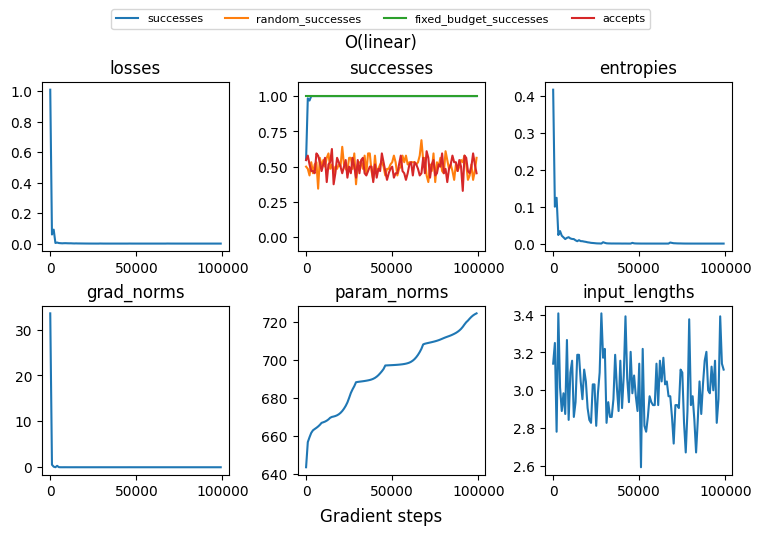

In [20]:
keys = [
    "losses",
    "successes",
    "entropies",
    "grad_norms",
    "param_norms",
    "input_lengths",
]

num_cols = 3
num_rows = math.ceil(len(keys) / num_cols)

fig, axes = plt.subplots(
    num_rows,
    num_cols,
    layout="constrained",
    figsize=(2.5 * num_cols, 2.5 * num_rows),
)

axes = axes.flatten()
for ax_i, key in enumerate(keys):
    ax = axes[ax_i]

    value = smoothed_res[key]
    if key == "successes":
        ax.plot(smoothed_iter, value, label=key)
        ax.plot(
            smoothed_iter,
            smoothed_res["random_successes"],
            label="random_successes",
        )
        ax.plot(
            smoothed_iter,
            smoothed_res["fixed_successes"],
            label="fixed_budget_successes",
        )
        ax.plot(
            smoothed_iter,
            smoothed_res["accepts"],
            label="accepts",
        )
    else:
        ax.plot(smoothed_iter, value)
    ax.set_title(key)

    if key == "successes":
        ax.set_ylim(-0.1, 1.1)

for i in range(len(keys), len(axes)):
    fig.delaxes(axes[i])

fig.suptitle("O({})".format(
    complexity if complexity != "constant" else read_budget
))
fig.supxlabel("Gradient steps")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=4,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8",
)

In [21]:
import dill

dill.dump(
    logs.train_state,
    open("latent_thoughts_run-{}-input_len_{}-{}-{}-train_steps_{}{}.dill".format(
        model_type,
        max_input_len - 1,
        train_type,
        f"constant_{read_budget}" if complexity == "constant" else complexity,
        max_iter,
        "-skip_connection" if use_skip_connection else ""
    ), "wb")
)

# Evaluation

In [22]:
if 0:
    import dill

    train_state = dill.load(
        open("latent_thoughts_run-{}-input_len_{}-{}-{}-train_steps_{}{}.dill".format(
            model_type,
            max_input_len - 1,
            train_type,
            f"constant_{read_budget}" if complexity == "constant" else complexity,
            max_iter,
            "-skip_connection" if use_skip_connection else ""
        ), "rb")
    )

    logs = LogStepState(
        train_state,
        jnp.zeros(math.ceil(max_iter / log_interval)),
        jnp.zeros(math.ceil(max_iter / log_interval)),
        jnp.zeros(math.ceil(max_iter / log_interval)),
        jnp.zeros(math.ceil(max_iter / log_interval)),
        jnp.zeros(math.ceil(max_iter / log_interval)),
        jnp.zeros(math.ceil(max_iter / log_interval)),
        jnp.zeros(math.ceil(max_iter / log_interval)),
        jnp.zeros(math.ceil(max_iter / log_interval)),
        jnp.zeros(math.ceil(max_iter / log_interval)),
    )

In [ ]:
successes = []
for heldout_input_len in range(max_input_len + 1, max_read_len):
    eval_logs = jax.lax.fori_loop(
        0,
        max_eval_iter,
        make_eval_step(
            partial(heldout_decision_batch, heldout_input_len=heldout_input_len),
            loss_constructor(read_budget if complexity == "constant" else heldout_input_len),
        ),
        EvalLogStepState(
            logs.train_state,
            jnp.zeros(math.ceil(max_eval_iter / log_interval)),
            jnp.zeros(math.ceil(max_eval_iter / log_interval)),
            jnp.zeros(math.ceil(max_eval_iter / log_interval)),
            jnp.zeros(math.ceil(max_eval_iter / log_interval)),
            jnp.zeros(math.ceil(max_eval_iter / log_interval)),
            jnp.zeros(math.ceil(max_eval_iter / log_interval)),
            jnp.zeros(math.ceil(max_eval_iter / log_interval)),
        )
    )

    successes.append(eval_logs.successes.mean())

Running for 50,000 iterations:   0%|          | 0/50000 [00:00<?, ?it/s]

In [ ]:
plt.plot(
    range(max_input_len + 1, max_read_len),
    successes,
    label="heldout_success_rate",
)

In [27]:
assert 0

AssertionError: 

## Debug

In [75]:
batch = heldout_decision_batch(sample_rng, heldout_input_len=heldout_input_len)

In [76]:
batch["question"]

Array([[1, 0, 0, 0, 1, 0, 1, 2, 4, 4, 4],
       [0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4],
       [1, 0, 1, 0, 1, 1, 0, 2, 4, 4, 4],
       [0, 0, 1, 0, 0, 1, 1, 2, 4, 4, 4],
       [0, 1, 0, 0, 0, 1, 0, 2, 4, 4, 4],
       [1, 1, 1, 0, 0, 1, 1, 2, 4, 4, 4],
       [0, 1, 0, 1, 1, 1, 0, 2, 4, 4, 4],
       [1, 1, 0, 1, 0, 0, 0, 2, 4, 4, 4],
       [0, 0, 0, 1, 1, 0, 1, 2, 4, 4, 4],
       [1, 0, 0, 1, 1, 0, 0, 2, 4, 4, 4],
       [0, 0, 1, 0, 0, 1, 0, 2, 4, 4, 4],
       [1, 1, 0, 0, 1, 0, 0, 2, 4, 4, 4],
       [1, 1, 0, 0, 1, 0, 1, 2, 4, 4, 4],
       [0, 1, 1, 0, 0, 0, 0, 2, 4, 4, 4],
       [1, 0, 0, 0, 0, 1, 1, 2, 4, 4, 4],
       [0, 0, 1, 1, 0, 0, 1, 2, 4, 4, 4],
       [0, 0, 1, 1, 0, 0, 0, 2, 4, 4, 4],
       [0, 1, 1, 1, 0, 1, 1, 2, 4, 4, 4],
       [0, 0, 1, 1, 1, 1, 1, 2, 4, 4, 4],
       [1, 0, 0, 0, 0, 1, 1, 2, 4, 4, 4],
       [1, 0, 0, 0, 1, 0, 0, 2, 4, 4, 4],
       [0, 1, 0, 1, 1, 0, 0, 2, 4, 4, 4],
       [1, 0, 1, 1, 0, 1, 1, 2, 4, 4, 4],
       [0, 1, 1, 0, 1, 0, 1, 2, 4,

In [77]:
batch["last_prompt_idx"]

Array([7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],      dtype=int32, weak_type=True)

In [78]:
read_budget = read_budget if complexity == "constant" else heldout_input_len

In [79]:
last_prompt_idx = batch["last_prompt_idx"]
last_prompt_idx = jax.lax.select(
    read_budget < last_prompt_idx,
    jnp.full_like(
        last_prompt_idx,
        fill_value=read_budget,
    ),
    last_prompt_idx,
)


In [80]:
question = batch["question"]
answer = batch["answer"]
last_prompt_idx = batch["last_prompt_idx"]
thought_length = batch["thought_length"]
answer_length = batch["answer_length"]

thought_length = jax.lax.select(
    read_budget - 1 < last_prompt_idx,
    jnp.ones_like(thought_length),
    thought_length - (last_prompt_idx - read_budget + 1),
)
last_prompt_idx = jax.lax.select(
    read_budget - 1 < last_prompt_idx,
    jnp.full_like(
        last_prompt_idx,
        fill_value=read_budget - 1,
    ),
    last_prompt_idx,
)

# total_len = last_prompt_idx + thought_length + answer_length
module = nnx.merge(logs.train_state.graphdef, logs.train_state.params, logs.train_state.rest)
_, init_cache = make_autoregressive(
    module,
    max_decode_len=output_phase_len,
    batch_size=1,
    embed_dim=embed_dim,
    dtype=dtype,
    eval_mode=True,
)
cache = init_cache()
graphdef, _, rest = nnx.split(module, nnx.Cache, ...)

question_embedding = module.get_embedding(question)

def initialize_read_step_state(question_embedding, last_prompt_idx):
    return ReadStepState(
        graphdef=graphdef,
        rest=rest,
        cache=cache,
        question_embedding=question_embedding,
        last_prompt_idx=last_prompt_idx,
        last_output=jnp.zeros((1, embed_dim)),
    )

def initialize_think_step_state(thought_length, last_read_output, read_cache):
    thought = jnp.zeros((1, max_thought_len, embed_dim))
    thought = thought.at[:, 0].set(last_read_output)
    return ThinkStepState(
        graphdef=graphdef,
        rest=rest,
        cache=read_cache,
        thought_length=thought_length,
        thought=thought,
    )

def initialize_teacher_forcing_step_state(think_cache, last_read_output, rng):
    actions = jnp.zeros((1, max_output_len + 1), dtype=int)
    actions = actions.at[:, 0].set(end_thinking_token)
    return TeacherForcingStepState(
        graphdef=graphdef,
        rest=rest,
        cache=think_cache,
        rng=rng,
        act_embeds=jnp.zeros((1, max_output_len + 1, embed_dim)),
        logits=jnp.zeros((1, max_output_len + 1, num_output_tokens)),
        actions=actions,
        last_read_output=last_read_output,
    )

read_step_state = nnx.vmap(initialize_read_step_state)(
    question_embedding[:, None],
    last_prompt_idx,
)

read_step_state = jax.lax.fori_loop(
    0,
    max_read_len,
    read_step,
    read_step_state,
)

think_step_state = nnx.vmap(initialize_think_step_state)(
    thought_length,
    read_step_state.last_output,
    read_step_state.cache,
)

think_step_state = jax.lax.fori_loop(
    0,
    max_thought_len,
    think_step,
    think_step_state,
)

teacher_forcing_step_state = nnx.vmap(initialize_teacher_forcing_step_state)(
    think_step_state.cache,
    jax.lax.select(
        use_skip_connection,
        read_step_state.last_output,
        jnp.zeros_like(read_step_state.last_output),
    ),
    rollout_rng
)

teacher_forcing_step_state = jax.lax.fori_loop(
    0,
    max_output_len,
    teacher_forcing_step,
    teacher_forcing_step_state,
)

logits = teacher_forcing_step_state.logits[:, 0, 1:]

actions = jnp.argmax(logits, axis=-1)
res = jax.vmap(match_action)(actions, answer, answer_length)
match_mask = res["mask"]
success = res["success"]

In [81]:
read_step_state.last_prompt_idx

Array([7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],      dtype=int32, weak_type=True)

In [82]:
success

Array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],      dtype=int32)

In [83]:
jnp.mean(success)

Array(0.984375, dtype=float32)

In [84]:
jnp.mean(batch["answer"])

Array(0.515625, dtype=float32)

In [85]:
jnp.argmax(logits, axis=-1)[:, 0]

Array([1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1],      dtype=int32)

In [86]:
batch["last_prompt_idx"]

Array([7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],      dtype=int32, weak_type=True)

In [87]:
jnp.where(batch["question"][:, 0] == 1)

(Array([ 0,  2,  5,  7,  9, 11, 12, 14, 19, 20, 22, 24, 25, 27, 28, 29, 30,
        32, 33, 34, 35, 36, 39, 41, 42, 45, 50, 53, 55, 56, 58, 62, 63],      dtype=int32),)

In [88]:
batch["question"][np.where(batch["answer"][:, 0] != jnp.argmax(logits, axis=-1)[:, 0])]

Array([[1, 1, 1, 0, 1, 1, 1, 2, 4, 4, 4]], dtype=int32)

In [92]:
batch["question"][np.where(batch["question"][:, heldout_input_len - 2] == 1)][:, :heldout_input_len]

Array([[1, 0, 0, 0, 1, 0, 1, 2],
       [0, 0, 1, 0, 0, 1, 1, 2],
       [1, 1, 1, 0, 0, 1, 1, 2],
       [0, 0, 0, 1, 1, 0, 1, 2],
       [1, 1, 0, 0, 1, 0, 1, 2],
       [1, 0, 0, 0, 0, 1, 1, 2],
       [0, 0, 1, 1, 0, 0, 1, 2],
       [0, 1, 1, 1, 0, 1, 1, 2],
       [0, 0, 1, 1, 1, 1, 1, 2],
       [1, 0, 0, 0, 0, 1, 1, 2],
       [1, 0, 1, 1, 0, 1, 1, 2],
       [0, 1, 1, 0, 1, 0, 1, 2],
       [1, 0, 1, 1, 0, 1, 1, 2],
       [1, 1, 1, 1, 1, 1, 1, 2],
       [1, 1, 1, 0, 1, 1, 1, 2],
       [1, 0, 0, 0, 0, 1, 1, 2],
       [1, 0, 1, 1, 0, 1, 1, 2],
       [0, 1, 0, 1, 0, 1, 1, 2],
       [1, 1, 1, 1, 1, 1, 1, 2],
       [0, 0, 0, 1, 0, 0, 1, 2],
       [1, 1, 1, 0, 0, 1, 1, 2],
       [0, 1, 0, 1, 0, 0, 1, 2],
       [1, 1, 0, 1, 0, 0, 1, 2],
       [0, 0, 1, 1, 0, 0, 1, 2],
       [0, 1, 1, 0, 1, 0, 1, 2],
       [0, 0, 0, 1, 0, 0, 1, 2],
       [0, 1, 0, 0, 1, 0, 1, 2],
       [0, 0, 1, 1, 0, 0, 1, 2],
       [1, 1, 0, 0, 0, 1, 1, 2],
       [0, 0, 0, 1, 1, 0, 1, 2],
       [1,